# Step 11 -- 2D Helmholtz Equation

The [Helmholtz equation](https://en.wikipedia.org/wiki/Helmholtz_equation) generalises the Poisson equation with a screening term:

$$
(\nabla^2 - \lambda)\,\phi = f
$$

When $\lambda = 0$ this reduces to the Poisson equation from Step 10.  When $\lambda > 0$ the extra term *screens* the solution -- suppressing long-range influences and reducing the amplitude.

**Physics:**

- **Quasi-geostrophic PV inversion:** $(\nabla^2 - F)\psi = q$, where $F$ is the inverse Rossby deformation radius squared.  Larger $F$ (smaller deformation radius) screens the flow, making eddies more localised.
- **Yukawa screening:** In plasma physics and particle physics, the screened Poisson equation models exponentially-decaying potentials.
- **Reaction-diffusion steady states:** Diffusion with linear decay leads to a Helmholtz-type equation.

**What you will learn:**

1. How to create and use the `HelmholtzSolver2D`
2. How increasing $\lambda$ screens the solution
3. That $\lambda = 0$ recovers the Poisson solution exactly

## Arakawa C-Grid and Boundary Conditions

The solver operates on a 2D Arakawa C-grid where scalar fields (temperature, pressure, streamfunction) live at cell centres and velocity components live on cell faces:

```
       V_{j+1/2}
    ┌─────●─────┐
    │           │
 U  ●     T     ●  U
i-1/2   (i,j)    i+1/2
    │           │
    └─────●─────┘
       V_{j-1/2}
```

The spectral solver operates on **interior cells** only.  The boundary condition type determines which spectral transform is used.

**Dirichlet BCs** ($\phi = 0$ on boundary): The DST (Discrete Sine Transform) automatically enforces zero values at the domain edges. Ghost cells are set to the negative of the nearest interior cell: `ghost = -interior` (antisymmetric). The Helmholtz screening parameter $\lambda$ does not change the boundary treatment -- it only modifies the spectral-space eigenvalues from $\lambda_{mn}$ to $\lambda_{mn} - \lambda$.

In [1]:
from __future__ import annotations

import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import HelmholtzSolver2D, PoissonSolver2D

## 1. Setup

We use a sinusoidal source term $f = \sin(\pi x)\sin(\pi y)$ on $[0,1]^2$ with homogeneous Dirichlet BCs and solve the Helmholtz equation at several values of $\lambda$.

In [2]:
nx, ny = 64, 64
Lx, Ly = 1.0, 1.0

# Build a reference Poisson solver
poisson = PoissonSolver2D.create(nx=nx, ny=ny, Lx=Lx, Ly=Ly, bc="dirichlet")
x = jnp.arange(poisson.grid.Nx) * poisson.grid.dx
y = jnp.arange(poisson.grid.Ny) * poisson.grid.dy
X, Y = jnp.meshgrid(x, y)

# Source term
rhs = jnp.sin(jnp.pi * X) * jnp.sin(jnp.pi * Y)

## 2. Screening effect

We solve $(\nabla^2 - \lambda)\phi = f$ for $\lambda \in \{0, 1, 10, 100\}$.  As $\lambda$ increases the solution amplitude should decrease and the field should become more localised.

In [3]:
lambdas = [0.0, 1.0, 10.0, 100.0]
solutions = {}

for lam in lambdas:
    solver = HelmholtzSolver2D.create(
        nx=nx, ny=ny, Lx=Lx, Ly=Ly, lambda_=lam, bc="dirichlet"
    )
    phi = solver.solve(rhs)
    solutions[lam] = phi
    amp = float(jnp.max(jnp.abs(phi[1:-1, 1:-1])))
    print(f"lambda = {lam:6.1f}  max|phi| = {amp:.6f}")

lambda =    0.0  max|phi| = 0.053551
lambda =    1.0  max|phi| = 0.050761
lambda =   10.0  max|phi| = 0.034598
lambda =  100.0  max|phi| = 0.008362


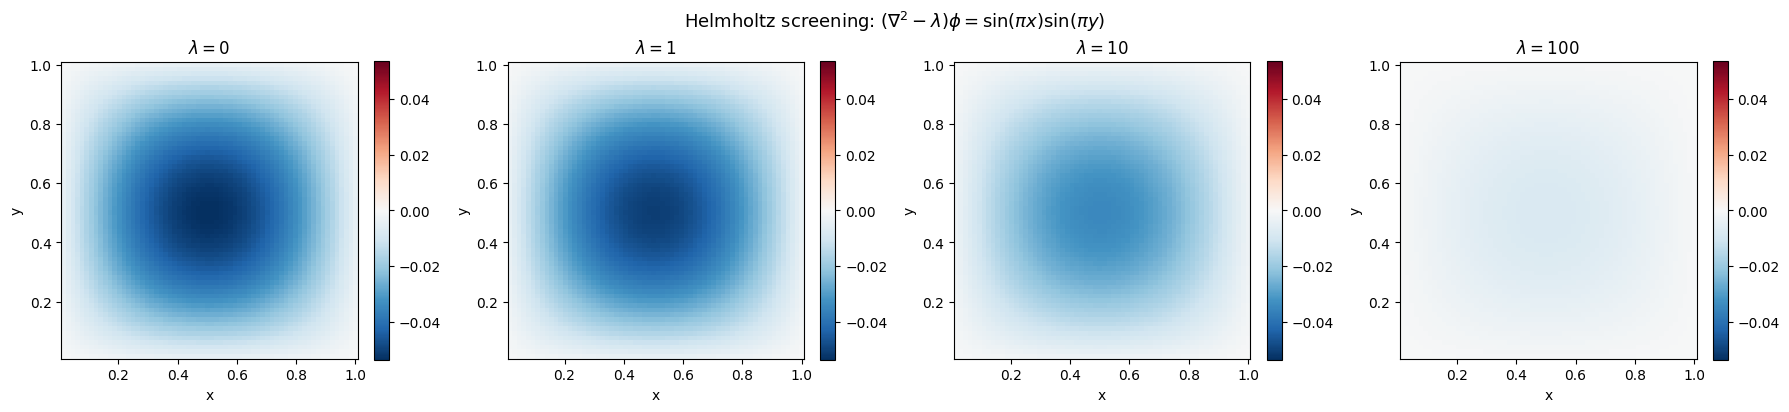

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Use a shared colour range based on the lambda=0 solution
vmax = float(jnp.max(jnp.abs(solutions[0.0][1:-1, 1:-1])))

for ax, lam in zip(axes, lambdas, strict=False):
    phi = solutions[lam]
    im = ax.pcolormesh(
        X[1:-1, 1:-1],
        Y[1:-1, 1:-1],
        phi[1:-1, 1:-1],
        shading="auto",
        vmin=-vmax,
        vmax=vmax,
        cmap="RdBu_r",
    )
    ax.set_title(rf"$\lambda = {lam:.0f}$")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(
    r"Helmholtz screening: $(\nabla^2 - \lambda)\phi = \sin(\pi x)\sin(\pi y)$",
    fontsize=13,
)
plt.tight_layout()
plt.show()

The amplitude drops dramatically with increasing $\lambda$. Physically, the screening term $-\lambda\phi$ acts as a restoring force that penalises large values of $\phi$, pulling the solution toward zero.

## 3. Cross-section comparison

A 1D slice along $y = 0.5$ (the centre row) shows the screening effect more clearly.

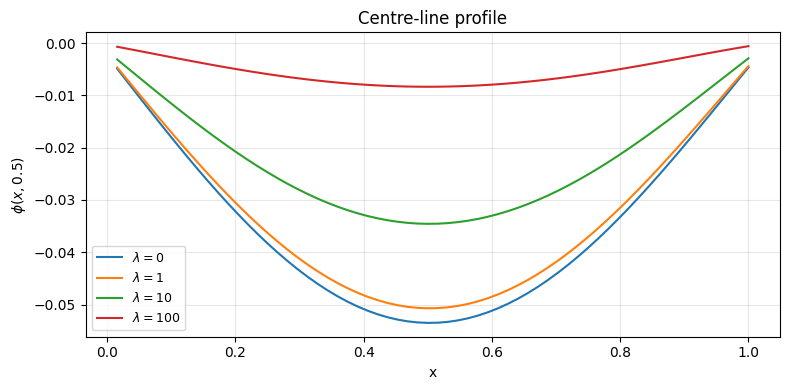

In [5]:
mid_j = poisson.grid.Ny // 2

fig, ax = plt.subplots(figsize=(8, 4))
for lam in lambdas:
    phi = solutions[lam]
    ax.plot(
        x[1:-1],
        phi[mid_j, 1:-1],
        label=rf"$\lambda = {lam:.0f}$",
        lw=1.5,
    )
ax.set_xlabel("x")
ax.set_ylabel(r"$\phi(x, 0.5)$")
ax.set_title("Centre-line profile")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Helmholtz at $\lambda = 0$ matches Poisson

When $\lambda = 0$ the Helmholtz equation reduces to the Poisson equation.  We verify that the two solvers produce identical results.

In [6]:
phi_poisson = poisson.solve(rhs)
phi_helm0 = solutions[0.0]

diff = jnp.max(jnp.abs(phi_poisson - phi_helm0))
print(f"Max |Poisson - Helmholtz(lambda=0)|: {float(diff):.2e}")

Max |Poisson - Helmholtz(lambda=0)|: 0.00e+00


The difference is at machine precision, confirming that the Helmholtz solver generalises the Poisson solver correctly.

> **Connection to finitevolX:**  For more advanced use cases (e.g. multilayer QG models), `somax` also provides `DirichletHelmholtzCache` which wraps the `DirichletHelmholtzSolver2D` from `spectraldiffx` with a pre-configured Helmholtz parameter.  See `somax._src.core.helmholtz` for details.

## 5. Amplitude vs. $\lambda$

For the single-mode source $f = \sin(\pi x)\sin(\pi y)$, the analytical solution of the Helmholtz equation is:

$$
\phi = \frac{f}{-2\pi^2 - \lambda}
$$

So the peak amplitude scales as $1 / (2\pi^2 + \lambda)$.  Let us verify this over a wider range of $\lambda$.

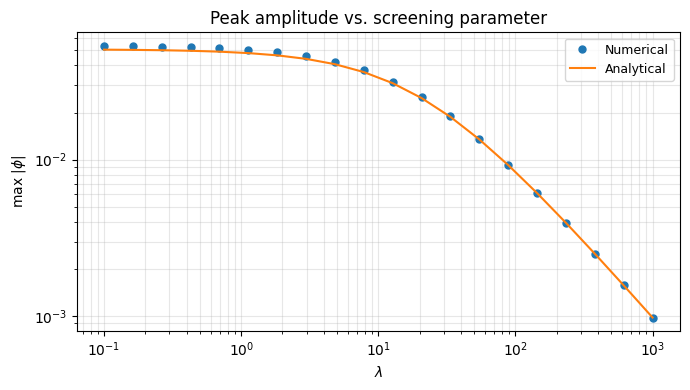

In [7]:
lambda_range = jnp.logspace(-1, 3, 20)
amps_num = []
amps_ana = []

for lam in lambda_range:
    solver = HelmholtzSolver2D.create(
        nx=nx, ny=ny, Lx=Lx, Ly=Ly, lambda_=float(lam), bc="dirichlet"
    )
    phi = solver.solve(rhs)
    amps_num.append(float(jnp.max(jnp.abs(phi[1:-1, 1:-1]))))
    # Analytical peak: 1 / (2*pi^2 + lambda) * peak(rhs)
    amps_ana.append(1.0 / (2.0 * jnp.pi**2 + float(lam)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(lambda_range, amps_num, "o", label="Numerical", markersize=5)
ax.loglog(lambda_range, amps_ana, "-", label="Analytical", lw=1.5)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"max $|\phi|$")
ax.set_title(r"Peak amplitude vs. screening parameter")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Summary

| Concept | API |
|---------|-----|
| Create Helmholtz solver | `HelmholtzSolver2D.create(nx, ny, lambda_=..., bc=...)` |
| Solve | `solver.solve(rhs)` |
| Poisson limit | `lambda_=0.0` recovers Poisson exactly |
| Screening | Larger $\lambda$ reduces amplitude and range |
| QG connection | $(\nabla^2 - F)\psi = q$ for PV inversion |

**Next:** [Step 12](step12_cavity_flow) tackles the full Navier--Stokes equations with the lid-driven cavity benchmark.